### Preservation

####  *AUTHOR:* Ehsan Farahbakhsh
####  *CONTACT:* e.farahbakhsh@sydney.edu.au
####  *DATE last modified:* 16/09/2025

This notebook estimates the likelihood of preservation using cumulative erosion grids generated by landscape evolution models. The results will refine the mineralisation probability calculated in notebook `05_prospectivity_map` and enable the calculation of preserved mineralisation probability.

The workflow is as follows:
1. Coregister points with cumulative erosion grids.
2. Apply a gamma distribution to transform cumulative deposition values into preservation likelihoods (capturing how likely mineral deposits are to have survived erosion as a surface process).  
3. Multiply preservation likelihood by mineralisation probability to produce a map of preserved mineralisation probability.  

This final map highlights areas where mineralisation is not only likely to have formed but also has a high chance of still being discovered today.  

We begin by importing the required libraries:

In [1]:
# Import libraries
from ipywidgets import interact
import warnings

import cartopy.crs as ccrs
import gplately
import joblib
from joblib import dump
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import (
    fit,
    gengamma,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler

# Note: Ensure the 'lib' folder is located in the same folder as this notebook
from lib.preservation import *
from lib.feature_extraction import *
from lib.predictive_modelling import *
from lib.prospectivity_map import *
from lib.plot import *

# Load configuration parameters (e.g., paths, model names)
from parameters import parameters

### Setup

As defined in `parameters.py`, the cell below configures the analysis parameters and specifies the paths to input/output files and directories. You can also specify the number of cores to use by setting an appropriate value for the `n_jobs` variable at the end of the cell.

**Note:** You can modify the analysis settings directly in `parameters.py`, located in the same folder as this notebook. The file is structured as a dictionary; look for keys such as `timespan` and `temporal_resolution` to adjust their values as needed.

In [2]:
# Set up temporal analysis parameters
temporal_resolution = parameters["temporal_resolution"]
time_min = parameters["timespan"]["min"] # Youngest time to analyse
time_max = parameters["timespan"]["max"] # Oldest time to analyse
# Create an array of time steps for analysis (e.g., 0, 1, 2, ... Ma)
time_steps = range(time_min, time_max + temporal_resolution, temporal_resolution)

grid_resolution = parameters["grid_resolution"]

# Directory paths for inputs and outputs
plate_model_dir = parameters["plate_model_dir"]
inputs_dir = parameters["inputs_dir"]
outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]
pres_dir = parameters["pres_dir"]
backarc_pres_grids_dir = parameters["backarc_pres_grids_dir"]
backarc_pres_maps_dir = parameters["backarc_pres_maps_dir"]
coastline_pres_grids_dir = parameters["coastline_pres_grids_dir"]
coastline_pres_maps_dir = parameters["coastline_pres_maps_dir"]
backarc_prob_pres_grids_dir = parameters["backarc_prob_pres_grids_dir"]
backarc_prob_pres_maps_dir = parameters["backarc_prob_pres_maps_dir"]
coastline_prob_pres_grids_dir = parameters["coastline_prob_pres_grids_dir"]
coastline_prob_pres_maps_dir = parameters["coastline_prob_pres_maps_dir"]

# Construct full directory paths
ml_dir = os.path.join(outputs_dir, ml_dir)
pres_dir = os.path.join(outputs_dir, pres_dir)
if not os.path.exists(pres_dir):
    os.makedirs(pres_dir, exist_ok=True)
backarc_pres_grids_dir = os.path.join(pres_dir, "backarc_pres_grids")
backarc_pres_maps_dir = os.path.join(pres_dir, "backarc_pres_maps")
coastline_pres_grids_dir = os.path.join(pres_dir, "coastline_pres_grids")
coastline_pres_maps_dir = os.path.join(pres_dir, "coastline_pres_maps")
backarc_prob_pres_grids_dir = os.path.join(ml_dir, backarc_prob_pres_grids_dir)
backarc_prob_pres_maps_dir = os.path.join(ml_dir, backarc_prob_pres_maps_dir)
coastline_prob_pres_grids_dir = os.path.join(ml_dir, coastline_prob_pres_grids_dir)
coastline_prob_pres_maps_dir = os.path.join(ml_dir, coastline_prob_pres_maps_dir)

# Data filenames
deposit_coords_recon_filename = parameters["deposit_coords_recon_filename"]
unlabelled_coords_filename = parameters["unlabelled_coords_filename"]
backarc_coords_filename = parameters["backarc_coords_filename"]
coastline_coords_filename = parameters["coastline_coords_filename"]
gengamma_dist_filename = parameters["gengamma_dist_filename"]
deposit_ero_filename = parameters["deposit_ero_filename"]
unlabelled_ero_filename = parameters["unlabelled_ero_filename"]
backarc_ero_filename = parameters["backarc_ero_filename"]
coastline_ero_filename = parameters["coastline_ero_filename"]
deposit_coords_recon_all_filename = parameters["deposit_coords_recon_all_filename"]
backarc_prob_filename = parameters["backarc_prob_filename"]
coastline_prob_filename = parameters["coastline_prob_filename"]
coastline_prob_present_day_filename = parameters["coastline_prob_present_day_filename"]
coastline_prob_pres_present_day_grid_filename = parameters["coastline_prob_pres_present_day_grid_filename"]
coastline_data_filename = parameters["coastline_data_filename"]

model_rf_calibrated_filename = parameters["model_rf_calibrated_filename"]

# Construct full file paths
deposit_coords_recon_filename = os.path.join(outputs_dir, deposit_coords_recon_filename)
unlabelled_coords_filename = os.path.join(outputs_dir, unlabelled_coords_filename)
backarc_coords_filename = os.path.join(outputs_dir, backarc_coords_filename)
coastline_coords_filename = os.path.join(outputs_dir, coastline_coords_filename)
gengamma_dist_filename = os.path.join(pres_dir, gengamma_dist_filename)
deposit_ero_filename = os.path.join(pres_dir, deposit_ero_filename)
unlabelled_ero_filename = os.path.join(pres_dir, unlabelled_ero_filename)
backarc_ero_filename = os.path.join(pres_dir, backarc_ero_filename)
coastline_ero_filename = os.path.join(pres_dir, coastline_ero_filename)
deposit_coords_recon_all_filename = os.path.join(outputs_dir, deposit_coords_recon_all_filename)
backarc_prob_filename = os.path.join(ml_dir, backarc_prob_filename)
coastline_prob_filename = os.path.join(ml_dir, coastline_prob_filename)
coastline_prob_present_day_filename = os.path.join(ml_dir, coastline_prob_present_day_filename)
coastline_prob_pres_present_day_grid_filename = os.path.join(ml_dir, coastline_prob_pres_present_day_grid_filename)
coastline_data_filename = os.path.join(outputs_dir, coastline_data_filename)

model_rf_calibrated_filename = os.path.join(ml_dir, model_rf_calibrated_filename)

# Paths to different types of grids
agegrid_dir = os.path.join(inputs_dir, "SeafloorAge")
ero_dir = os.path.join(inputs_dir, "CumulativeErosion")

# Number of cores to be used for running this notebook
n_jobs = 20

### Coregistration

This code block coregisters different sets of points generated in previous notebooks—including reconstructed locations of mineral occurrences, unlabelled samples, and target points within arc–back-arc environments and continental landmasses—with cumulative erosion grids.  

For each point, it assigns the mean value of the grid pixels within a user-defined square neighborhood. The side length of this square is controlled by the `distance` argument in the function below.

In [3]:
columns_ero = ["present_lon", "present_lat", "lon", "lat", "age (Ma)"]

# Coregister deposit locations with cumulative erosion grids
# This links each deposit to its erosion history
if os.path.isfile(deposit_ero_filename):
    deposit_ero = pd.read_csv(deposit_ero_filename)
else:
    deposit_coords_recon = pd.read_csv(deposit_coords_recon_filename)
    deposit_ero = deposit_coords_recon[columns_ero]
    
    deposit_ero = run_coregister_erosion(
        point_data=deposit_ero,
        input_dir=ero_dir,
        distance_threshold=0.1,
        output_filename=deposit_ero_filename,
        n_jobs=n_jobs,
        verbose=True,
    )

# Coregister unlabelled samples with cumulative erosion grids
if os.path.isfile(unlabelled_ero_filename):
    unlabelled_ero = pd.read_csv(unlabelled_ero_filename)
else:
    unlabelled_coords = pd.read_csv(unlabelled_coords_filename)
    unlabelled_ero = unlabelled_coords[columns_ero]
    
    unlabelled_ero = run_coregister_erosion(
        point_data=unlabelled_ero,
        input_dir=ero_dir,
        distance_threshold=0.1,
        output_filename=unlabelled_ero_filename,
        n_jobs=n_jobs,
        verbose=True,
    )

# Coregister target points generated within arc-backarc environments with cumulative erosion grids
if os.path.isfile(backarc_ero_filename):
    backarc_ero = pd.read_csv(backarc_ero_filename)
else:
    backarc_coords = pd.read_csv(backarc_coords_filename)
    backarc_ero = backarc_coords[columns_ero]
    
    backarc_ero = run_coregister_erosion(
        point_data=backarc_ero,
        input_dir=ero_dir,
        distance_threshold=0.1,
        output_filename=backarc_ero_filename,
        n_jobs=n_jobs,
        verbose=True,
    )

# Coregister target points within continental landmasses with cumulative erosion grids
if os.path.isfile(coastline_ero_filename):
    coastline_ero = pd.read_csv(coastline_ero_filename)
else:
    coastline_coords = pd.read_csv(coastline_coords_filename)
    columns_ero.append("index")
    coastline_ero = coastline_coords[columns_ero]
    
    coastline_ero = run_coregister_erosion(
        point_data=coastline_ero,
        input_dir=ero_dir,
        distance_threshold=0.1,
        output_filename=coastline_ero_filename,
        n_jobs=n_jobs,
        verbose=True,
    )

Here, we generate a plot comparing the distribution of cumulative erosion values between known mineral occurrences and unlabelled samples.

Upper outlier threshold for positive samples: 6994.224781210694


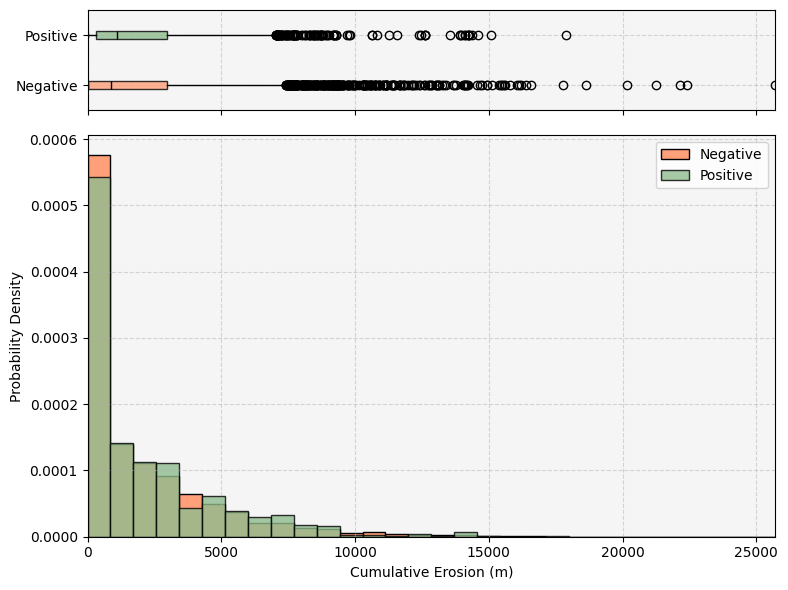

In [4]:
deposit_ero_col = deposit_ero["erosion (m)"]
unlabelled_ero_col = unlabelled_ero["erosion (m)"]

# Compute quartiles
Q1 = np.percentile(deposit_ero_col, 25)
Q3 = np.percentile(deposit_ero_col, 75)
IQR = Q3 - Q1

# Upper threshold for outliers
upper_threshold = Q3 + 1.5 * IQR

print("Upper outlier threshold for positive samples:", upper_threshold)

# Create figure with subplots - boxplot on top, histogram below
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(8, 6), 
                                      gridspec_kw={"height_ratios": [1, 4]})

# Set background color for both subplots
ax_box.set_facecolor("whitesmoke")
ax_hist.set_facecolor("whitesmoke")

# Create histogram
_, bins, _ = ax_hist.hist(
    unlabelled_ero_col,
    bins=30,
    facecolor="LightSalmon",
    edgecolor="black",
    label="Negative",
    density=True,
    alpha=1,
)
ax_hist.hist(
    deposit_ero_col,
    bins=bins,
    facecolor="DarkSeaGreen",
    edgecolor="black",
    label="Positive",
    density=True,
    alpha=0.8,
)

# Create boxplots with matching colors
box_data = [unlabelled_ero_col, deposit_ero_col]
box_colors = ["LightSalmon", "DarkSeaGreen"]
box_labels = ["Negative", "Positive"]

bp = ax_box.boxplot(box_data, 
                    positions=[1, 2],
                    tick_labels=box_labels,
                    patch_artist=True,
                    vert=False)  # Horizontal boxplots

# Color the boxplots to match histograms
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor("black")

# Style the boxplots
for element in ["whiskers", "fliers", "medians", "caps"]:
    plt.setp(bp[element], color="black")

# Set labels and formatting
ax_hist.set_xlabel("Cumulative Erosion (m)")
ax_hist.set_ylabel("Probability Density")
ax_hist.legend(loc="best")

# ax_box.set_ylabel("Samples")

# Add dashed gridlines to both subplots
ax_box.grid(True, linestyle="--", alpha=0.5)
ax_hist.grid(True, linestyle="--", alpha=0.5)

# Remove x-axis labels from boxplot to avoid duplication
ax_box.set_xticklabels([])

# Ensure both plots have the same x-axis limits
x_min = min(unlabelled_ero_col.min(), deposit_ero_col.min())
x_max = max(unlabelled_ero_col.max(), deposit_ero_col.max())
ax_box.set_xlim(x_min, x_max)
ax_hist.set_xlim(x_min, x_max)

# Adjust spacing between subplots
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)

plt.show()

### Removal of Outliers

To fit a suitable gamma function to the distribution of cumulative erosion values for known mineral occurrences, we first need to remove outliers.

The code cell below applies an Isolation Forest to identify and remove these outliers. The user can control the maximum proportion of data points removed by adjusting the `contamination` argument in the `clean_outliers_advanced` function.

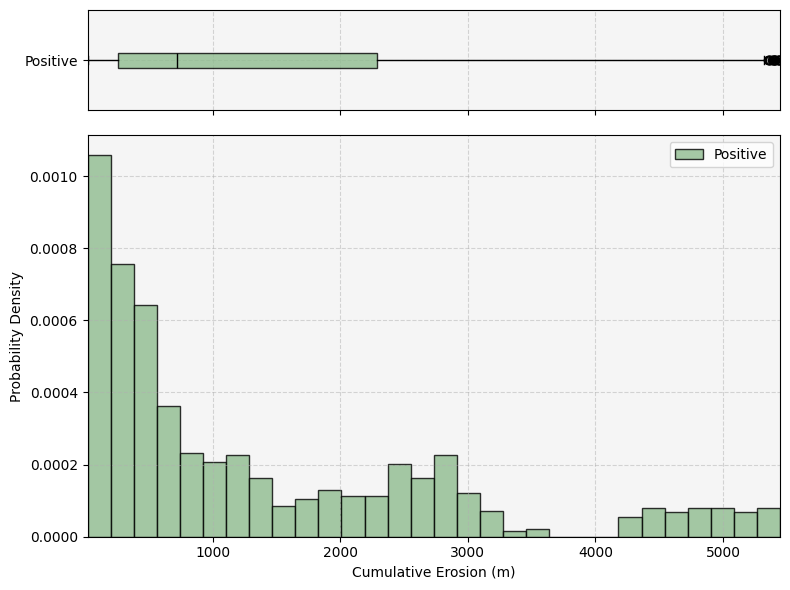

In [5]:
deposit_ero_clean = clean_outliers_advanced(deposit_ero_col, method="isolation_forest", contamination=0.15)

# Create figure with subplots - boxplot on top, histogram below
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(8, 6), 
                                      gridspec_kw={"height_ratios": [1, 4]})
# Set background color for both subplots
ax_box.set_facecolor("whitesmoke")
ax_hist.set_facecolor("whitesmoke")

# Create histogram
_, bins, _ = ax_hist.hist(
    # deposit_ero_col,
    deposit_ero_clean,
    bins=30,
    facecolor="DarkSeaGreen",
    edgecolor="black",
    label="Positive",
    density=True,
    alpha=0.8,
)

# Create boxplot
bp = ax_box.boxplot(
    # [deposit_ero_col],
    [deposit_ero_clean],
    positions=[1],
    tick_labels=["Positive"],
    patch_artist=True,
    vert=False
)

# Color the boxplot
bp["boxes"][0].set_facecolor("DarkSeaGreen")
bp["boxes"][0].set_alpha(0.8)
bp["boxes"][0].set_edgecolor("black")

# Style the boxplot
for element in ["whiskers", "fliers", "medians", "caps"]:
    plt.setp(bp[element], color="black")

# Set labels and formatting
ax_hist.set_xlabel("Cumulative Erosion (m)")
ax_hist.set_ylabel("Probability Density")
ax_hist.legend(loc="best")

# Add dashed gridlines to both subplots
ax_box.grid(True, linestyle="--", alpha=0.5)
ax_hist.grid(True, linestyle="--", alpha=0.5)

# Remove x-axis labels from boxplot to avoid duplication
ax_box.set_xticklabels([])

# Set x-axis limits
# x_min = deposit_ero_col.min()
# x_max = deposit_ero_col.max()

x_min = deposit_ero_clean.min()
x_max = deposit_ero_clean.max()

ax_box.set_xlim(x_min, x_max)
ax_hist.set_xlim(x_min, x_max)

# Adjust spacing between subplots
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

### Generalised Gamma Distribution

Here, we fit a generalised gamma distribution to the cumulative erosion values at the locations of known mineral occurrences. The gamma distribution is a flexible statistical model often used to describe skewed data with long tails such as erosion magnitudes. It provides a way to capture the relationship between erosion magnitude and the probability of deposit preservation.

By fitting this distribution to the cumulative erosion data, we obtain a mathematical framework for estimating the likelihood that a deposit has been preserved given the erosion it has experienced. Higher erosion values imply a lower probability of preservation, while lower values suggest a greater chance that the deposit remains intact.

In [6]:
if os.path.isfile(gengamma_dist_filename):
    gengamma_dist = joblib.load(gengamma_dist_filename)
else:
    # Try two optimisation methods
    def optimize_func(*args, **kwargs):
        # Try differential_evolution first
        result1 = differential_evolution(*args, seed=42, maxiter=2000, **kwargs)
        if result1.success:
            return result1

        # Fallback to other methods
        from scipy.optimize import minimize
        result2 = minimize(*args, method="L-BFGS-B", **kwargs)
        return result2
    
    gengamma_bounds = {
        "a": (0.1, 10),
        "c": (-5, 5),
        "scale": (1, 5000)
    }
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        fitted_params = fit(
            gengamma,
            data=deposit_ero_clean,
            bounds=gengamma_bounds,
            optimizer=optimize_func,
        )
    
    # Abort or warn if optimisation fails
    if not fitted_params.success:
        failure = "raise"
        message = f"Optimisation failed! {fitted_params.message}"
        if failure == "raise":
            raise RuntimeError(message)
        else:
            warnings.warn(message, RuntimeWarning)
    
    # Create the fitted distribution object
    gengamma_dist = gengamma(*(fitted_params.params))
    # Negative log‑likelihood (lower = better fit)
    nll_parametric = -1 * gengamma_dist.logpdf(deposit_ero_clean).sum()
    # Cache the fitted distribution for future runs
    dump(gengamma_dist, gengamma_dist_filename, compress=True)
    
    print(f"Parametric (gamma) distribution: NLL = {nll_parametric:0.0f}")
    print(f"""Writing parametric distribution to file: {gengamma_dist_filename}""")

Here, we plot the distribution of observed cumulative erosion magnitudes as a histogram, alongside the fitted generalised gamma distribution curve. The histogram shows the actual cumulative erosion data at deposit sites, while the dashed line represents the smooth gamma model that statistically describes this data.  

By comparing the two, we can assess how well the gamma distribution captures the natural variability of erosion. This visualisation is important because it validates the statistical model used to estimate preservation likelihood, which is a key factor in understanding which deposits are more likely to have survived geological processes such as erosion.

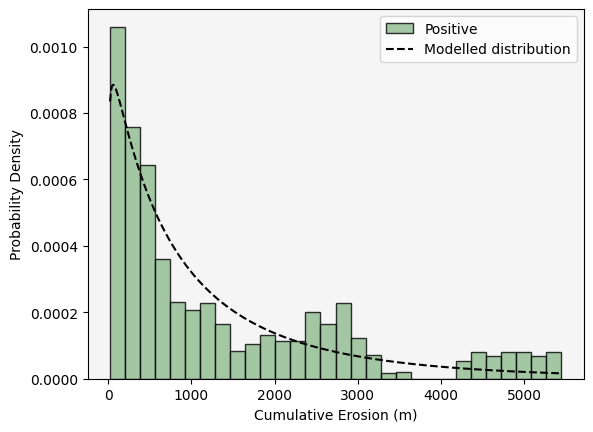

In [7]:
# Create x-values across the full range of cleaned erosion magnitudes
dist_x = np.linspace(
    deposit_ero_clean.min(),
    deposit_ero_clean.max(),
    500,
)
y_parametric = gengamma_dist.pdf(dist_x)

fig, ax = plt.subplots()
ax.set_facecolor("whitesmoke")

# Plot histogram of cumulative erosion magnitudes for known mineral occurrences
ax.hist(
    deposit_ero_clean,
    bins=30,
    facecolor="DarkSeaGreen",
    edgecolor="black",
    label="Positive",
    density=True, # Normalise to form a probability density
    alpha=0.8,
)

# Overlay the modelled gamma distribution curve to compare fit
ax.plot(
    dist_x,
    y_parametric,
    linestyle="dashed",
    color="black",
    label="Modelled distribution",
)

# Label axes
ax.set_xlabel("Cumulative Erosion (m)")
ax.set_ylabel("Probability Density")
ax.legend(loc="best")

### Q-Q Plot

This Quantile–Quantile (Q–Q) plot compares the observed cumulative erosion magnitudes at mineral occurrence locations with the theoretical values predicted by the fitted generalised gamma distribution. Each point represents how a specific quantile of the real data aligns with the corresponding quantile from the model. Points that fall near the red dashed 1:1 line indicate strong agreement between the model and the observed data. This provides a check on whether the generalised gamma distribution reliably captures the natural variability of erosion that influences deposit preservation.

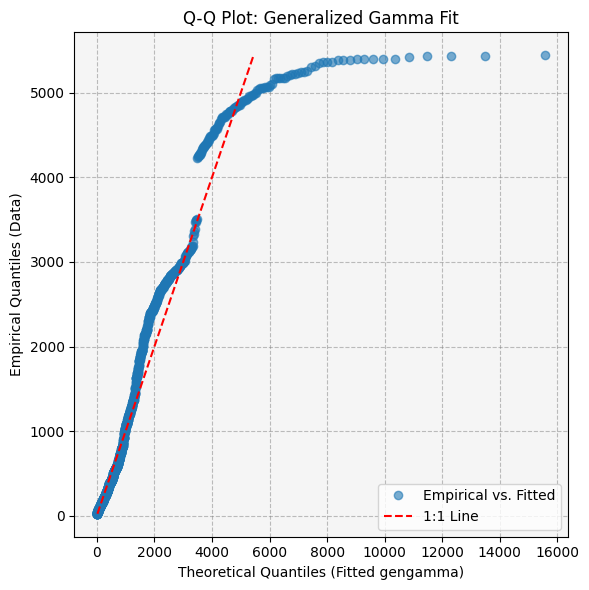

In [8]:
# Sort the empirical data
deposit_ero_sorted = np.sort(deposit_ero_clean)

# Compute theoretical quantiles from the fitted distribution
quantiles = np.linspace(0, 1, len(deposit_ero_sorted), endpoint=False)
theoretical_q = gengamma_dist.ppf(quantiles)

# Create Q-Q plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor("whitesmoke")

ax.plot(theoretical_q, deposit_ero_sorted, "o", label="Empirical vs. Fitted", alpha=0.6)
ax.plot([deposit_ero_sorted.min(), deposit_ero_sorted.max()],
        [deposit_ero_sorted.min(), deposit_ero_sorted.max()],
        "r--", label="1:1 Line")

# Set labels and title
ax.set_xlabel("Theoretical Quantiles (Fitted gengamma)")
ax.set_ylabel("Empirical Quantiles (Data)")
ax.set_title("Q-Q Plot: Generalized Gamma Fit")

# Add legend and grid
plt.legend()
plt.grid(linestyle="dashed", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

### Preservation Likelihood for Arc-Backarc Points

We estimate the likelihood of preservation for grid points generated within buffer zones covering arc–backarc environments by analysing their erosion history. The erosion depth is used to infer exhumation, while a fitted generalised gamma distribution models the preservation probability at each point. The resulting likelihood values are log-transformed and normalised to a 0–1 scale, enabling spatial comparison. The result highlights areas where mineral deposits are more likely to remain in the upper crust. These values are then stored and used to generate gridded spatiotemporal maps, supporting mineral prospectivity analysis.

In [9]:
if "preservation_likelihood_tran" in backarc_ero.columns:
    print(f"Preservation likelihood has already been calculated and saved in {backarc_ero_filename}")
else:
    # Use fitted gamma distribution to estimate preservation likelihood
    backarc_ero["preservation_likelihood"] = gengamma_dist.pdf(backarc_ero["erosion (m)"])
    preservation_likelihood = backarc_ero["preservation_likelihood"].values
    preservation_likelihood_clean = preservation_likelihood[~np.logical_or(np.isnan(preservation_likelihood), preservation_likelihood == 0)].reshape(-1, 1)
    
    transformer = make_pipeline(
        FunctionTransformer(np.log, np.exp, check_inverse=False),
        MinMaxScaler()
    ).fit(preservation_likelihood_clean)

    # Log-transform and normalise the preservation likelihood for grid output
    preservation_likelihood_tran = transformer.transform(preservation_likelihood_clean)
    backarc_ero.loc[~np.logical_or(np.isnan(preservation_likelihood), preservation_likelihood == 0), "preservation_likelihood_tran"] = preservation_likelihood_tran.flatten()
    # Assign perfect preservation to age = 0
    backarc_ero.loc[backarc_ero["age (Ma)"] == 0, "preservation_likelihood_tran"] = 1
    # Save updated table with computed preservation likelihoods
    backarc_ero.to_csv(backarc_ero_filename, index=False)

# Generate time-resolved preservation grids for the entire arc-backarc environments
if os.path.exists(backarc_pres_grids_dir):
    print(f"Preservation grids are located in {backarc_pres_grids_dir}")
else:
    os.makedirs(backarc_pres_grids_dir, exist_ok=True)

    create_grids(
        backarc_ero,
        output_dir=backarc_pres_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        threads=n_jobs,
        verbose=True,
        column="preservation_likelihood_tran",
        filename_format="backarc_preservation_grid_{}Ma.nc",
    )

Preservation likelihood has already been calculated and saved in outputs\preservation\backarc_ero.csv
Preservation grids are located in outputs\preservation\backarc_pres_grids


### Preservation Maps for Arc-Backarc Points

The cell below loads the necessary files to create the `PlateReconstruction` and `PlateTopologies` objects, which will later be used for reconstruction and generating visualisations.

In [10]:
# STELLAR4A plate motion model
rotation_model = plate_model_dir+"/CombinedRotations.rot"

topology_features = [
    plate_model_dir+"/Deforming_Networks_Active.gpml",
    plate_model_dir+"/Deforming_Networks_Inactive.gpml",
    plate_model_dir+"/Feature_Geometries.gpml",
    # plate_model_dir+"/Flat_Slabs.gpml", # Including this file may introduce artifacts, so it is recommended to exclude it when creating the PlateReconstruction object.
    plate_model_dir+"/Plate_Boundaries.gpml",
]

static_polygons = plate_model_dir+"/Global_EarthByte_GPlates_PresentDay_StaticPlatePolygons.gpml"
coastlines = plate_model_dir+"/Global_coastlines_low_res.gpml"
continents = plate_model_dir+"/Global_EarthByte_GPlates_PresentDay_ContinentsAndArcs.gpml"
COBs = plate_model_dir+"/Global_EarthByte_GeeK07_COBLineSegments_2019_v1.gpml"

plate_reconstruction = PlateReconstruction(
    rotation_model=rotation_model,
    topology_features=topology_features,
    static_polygons=static_polygons,
)

gplot = PlotTopologies(
    plate_reconstruction=plate_reconstruction,
    coastlines=coastlines,
    continents=continents,
    COBs=COBs,
)

# Define map projection (Mollweide provides a good global view) and central meridian
projection = ccrs.Mollweide(central_longitude=60)
central_meridian = 0

This section generates an interactive preservation likelihood map that displays values along trench lines, with the option to overlay known mineral occurrences. It also shows seafloor age and plate boundaries—including mid-ocean ridges and transform faults—at a selected time. The visualisation highlights areas favourable for the preservation of mineralisation, as well as regions subject to higher erosion rates that may have removed deposits or transported them to adjacent areas.

In [11]:
@interact
def show_map(time=time_steps):
    gplot.time = time # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            backarc_pres_grids_dir,
            f"backarc_preservation_grid_{time:0.0f}Ma.nc", # Preservation likelihood grid
        ),
        grid_type="preservation",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc", # Seafloor age grid
        ),
        # positives=deposit_coords_recon_all_filename, # Reconstructed location of known mineral occurrences
        positives=None,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

The cell below generates a full sequence of preservation likelihood maps through geological time and compiles them into a time-lapse animation, illustrating how the modelled preservation likelihood changes over time.

In [12]:
# Generate all preservation likelihood maps and create animation
if os.path.exists(backarc_pres_maps_dir):
    print(f"Preservation likelihood maps are located in {backarc_pres_maps_dir}")
else:
    os.makedirs(backarc_pres_maps_dir, exist_ok=True)

    # Create maps in parallel for efficiency
    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Define output filename for each time step
        output_filenames = [
            os.path.join(backarc_pres_maps_dir, f"backarc_preservation_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    backarc_pres_grids_dir,
                    f"backarc_preservation_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="preservation",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                # positives=deposit_recon_coords_all_filename,
                positives=None,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create an animation showing the evolution of preservation likelihood
    output_filename = os.path.join(pres_dir, "backarc_preservation_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Preservation likelihood maps are located in outputs\preservation\backarc_pres_maps


### Preserved Mineralisation Probability for Arc-Backarc Points

Here we combine mineralisation probability with preservation likelihood to estimate the probability that mineral deposits are both formed and retained in arc–backarc environments through time. Mineralisation probability is multiplied by the scaled preservation likelihood, and the combined results are stored as time-dependent grids. These grids display the spatial distribution of preserved mineralisation probability, taking into account erosion and exhumation. This approach enables more realistic mineral prospectivity mapping by explicitly incorporating preservation bias.

In [13]:
backarc_prob = pd.read_csv(backarc_prob_filename)

if "probability_pres" in backarc_prob.columns:
    print(f"Preserved mineralisation probability has already been calculated and saved in {backarc_prob_filename}")
else:
    # Sort the probability and erosion data
    backarc_prob = backarc_prob.sort_values(by=["age (Ma)", "present_lon", "present_lat"])
    backarc_ero = backarc_ero.sort_values(by=["age (Ma)", "present_lon", "present_lat"])

    # Calculate preserved mineralisation probability
    backarc_prob["probability_pres"] = backarc_prob["probability"] * backarc_ero["preservation_likelihood_tran"].fillna(1)
    backarc_prob.to_csv(backarc_prob_filename, index=False)

# Generate time-resolved preserved mineralisation probability grids
if os.path.exists(backarc_prob_pres_grids_dir):
    print(f"Preserved mineralisation probability grids are located in {backarc_prob_pres_grids_dir}")
else:
    os.makedirs(backarc_prob_pres_grids_dir, exist_ok=True)

    create_grids(
        backarc_prob,
        output_dir=backarc_prob_pres_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        threads=n_jobs,
        verbose=True,
        column="probability_pres",
        filename_format="backarc_probability_pres_grid_{}Ma.nc",
    )

Preserved mineralisation probability has already been calculated and saved in outputs\ml\backarc_prob.csv
Preserved mineralisation probability grids are located in outputs\ml\backarc_prob_pres_grids


This section generates an interactive map of preserved mineralisation probability displaying values along trench lines, with known mineral occurrences overlaid. It also shows seafloor age and plate boundaries—including mid-ocean ridges and transform faults—at a selected time. The visualisation highlights spatial patterns, illustrating how preserved mineralisation probability relates to tectonic features, surface processes, and temporal evolution, and how favourable conditions shift through time.

In [14]:
@interact
def show_map(time=time_steps):
    gplot.time = time # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            backarc_prob_pres_grids_dir,
            f"backarc_probability_pres_grid_{time:0.0f}Ma.nc", # Preserved mineralisation probability grid
        ),
        grid_type="probability_pres",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc", # Seafloor age grid
        ),
        positives=deposit_coords_recon_all_filename, # Reconstructed location of known mineral occurrences
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

The cell below generates a full sequence of preserved mineralisation probability maps through geological time and compiles them into a time-lapse animation, illustrating how the modelled probability changes over time.

In [15]:
# Generate all probability maps and create animation
if os.path.exists(backarc_prob_pres_maps_dir):
    print(f"Preserved mineralisation probability maps are located in {backarc_prob_pres_maps_dir}")
else:
    os.makedirs(backarc_prob_pres_maps_dir, exist_ok=True)

    # Create maps in parallel for efficiency
    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Define output filename for each time step
        output_filenames = [
            os.path.join(backarc_prob_pres_maps_dir, f"backarc_probability_pres_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    backarc_prob_pres_grids_dir,
                    f"backarc_probability_pres_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="probability_pres",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create an animation showing the evolution of preserved mineralisation probability
    output_filename = os.path.join(ml_dir, "backarc_probability_pres_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Preserved mineralisation probability maps are located in outputs\ml\backarc_prob_pres_maps


### Preservation Likelihood for Points within Continental Landmasses

Similar to arc-backarc points, we estimate the likelihood of preservation for grid points generated within continental landmasses by analysing their erosion history. The erosion depth is used to infer exhumation, while a fitted generalised gamma distribution models the preservation probability at each point. The resulting likelihood values are log-transformed and normalised to a 0–1 scale, enabling spatial comparison. The result highlights areas where mineral deposits are more likely to remain in the upper crust. These values are stored and used to generate gridded spatiotemporal maps, as well as a single global mineral prospectivity map in present-day coordinates. The global map integrates the history of all points within continental landmasses, accounting for both mineralisation and preservation.

In [16]:
if "preservation_likelihood_tran" in coastline_ero.columns:
    print(f"Preservation likelihood has already been calculated and saved in {coastline_ero_filename}")
else:
    # Use fitted gamma distribution to estimate preservation likelihood
    coastline_ero["preservation_likelihood"] = gengamma_dist.pdf(coastline_ero["erosion (m)"])
    preservation_likelihood = coastline_ero["preservation_likelihood"].values
    preservation_likelihood_clean = preservation_likelihood[~np.logical_or(np.isnan(preservation_likelihood), preservation_likelihood == 0)].reshape(-1, 1)

    transformer = make_pipeline(
        FunctionTransformer(np.log, np.exp, check_inverse=False),
        MinMaxScaler()
    ).fit(preservation_likelihood_clean)

    # Log-transform and normalise the preservation likelihood for grid output
    preservation_likelihood_tran = transformer.transform(preservation_likelihood_clean)
    coastline_ero.loc[~np.logical_or(np.isnan(preservation_likelihood), preservation_likelihood == 0.0), "preservation_likelihood_tran"] = preservation_likelihood_tran.flatten()
    # Assign perfect preservation to age = 0
    coastline_ero.loc[coastline_ero["age (Ma)"] == 0, "preservation_likelihood_tran"] = 1
    # Save updated table with computed preservation likelihoods
    coastline_ero.to_csv(coastline_ero_filename, index=False)

# Generate time-resolved preservation grids for the entire continental landmasses
if os.path.exists(coastline_pres_grids_dir):
    print(f"Preservation grids are located in {coastline_pres_grids_dir}")
else:
    os.makedirs(coastline_pres_grids_dir, exist_ok=True)

    create_grids(
        coastline_ero,
        output_dir=coastline_pres_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=n_jobs,
        verbose=True,
        column="preservation_likelihood_tran",
        filename_format="coastline_preservation_grid_{}Ma.nc",
    )

Preservation likelihood has already been calculated and saved in outputs\preservation\coastline_ero.csv
Preservation grids are located in outputs\preservation\coastline_pres_grids


### Preservation Maps for Points within Continental Landmasses

This section generates an interactive preservation likelihood map that displays values within continental landmasses, with the option to overlay known mineral occurrences. It also shows seafloor age and plate boundaries—including mid-ocean ridges and transform faults—at a selected time. The visualisation highlights areas favourable for the preservation of mineralisation, as well as regions subject to higher erosion rates that may have removed deposits or transported them to adjacent areas.

In [17]:
@interact
def show_map(time=time_steps):
    gplot.time = time # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_pres_grids_dir,
            f"coastline_preservation_grid_{time:0.0f}Ma.nc", # Preservation likelihood grid
        ),
        grid_type="preservation",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc", # Seafloor age grid
        ),
        # positives=deposit_coords_recon_all_filename, # Reconstructed location of known mineral occurrences
        positives=None,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

The cell below generates a full sequence of preservation likelihood maps through geological time and compiles them into a time-lapse animation, illustrating how the modelled preservation likelihood changes over time.

In [18]:
# Generate all preservation likelihood maps and create animation
if os.path.exists(coastline_pres_maps_dir):
    print(f"Preservation likelihood maps are located in {coastline_pres_maps_dir}")
else:
    os.makedirs(coastline_pres_maps_dir, exist_ok=True)

    # Create maps in parallel for efficiency
    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Define output filename for each time step
        output_filenames = [
            os.path.join(coastline_pres_maps_dir, f"coastline_preservation_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    coastline_pres_grids_dir,
                    f"coastline_preservation_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="preservation",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                # positives=deposit_recon_coords_all_filename,
                positives=None,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create an animation showing the evolution of preservation likelihood
    output_filename = os.path.join(pres_dir, "coastline_preservation_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Preservation likelihood maps are located in outputs\preservation\coastline_pres_maps


### Preserved Mineralisation Probability for Points within Continental Landmasses

Similar to arc-backarc points, we combine mineralisation probability with preservation likelihood to estimate the probability that mineral deposits are both formed and retained in continental landmasses through time. Mineralisation probability is multiplied by the scaled preservation likelihood, and the combined results are stored as time-dependent grids. These grids display the spatial distribution of preserved mineralisation probability, taking into account erosion and exhumation. This approach enables more realistic mineral prospectivity mapping by explicitly incorporating preservation bias.

In [19]:
coastline_prob = pd.read_csv(coastline_prob_filename)

if "probability_pres" in coastline_prob.columns:
    print(f"Preserved mineralisation probability has already been calculated and saved in {coastline_prob_filename}")
else:
    # Sort the probability and erosion data
    coastline_prob = coastline_prob.sort_values(by=["age (Ma)", "present_lon", "present_lat"])
    coastline_ero = coastline_ero.sort_values(by=["age (Ma)", "present_lon", "present_lat"])

    # Calculate preserved mineralisation probability
    coastline_prob["preservation_likelihood_tran"] = coastline_ero["preservation_likelihood_tran"].fillna(1)
    coastline_prob["probability_pres"] = coastline_prob["probability"] * coastline_prob["preservation_likelihood_tran"]
    coastline_prob.to_csv(coastline_prob_filename, index=False)

# Generate time-resolved preserved mineralisation probability grids
if os.path.exists(coastline_prob_pres_grids_dir):
    print(f"Preserved mineralisation probability grids are located in {coastline_prob_pres_grids_dir}")
else:
    os.makedirs(coastline_prob_pres_grids_dir, exist_ok=True)

    create_grids(
        coastline_prob,
        output_dir=coastline_prob_pres_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=n_jobs,
        verbose=True,
        column="probability_pres",
        filename_format="coastline_probability_pres_grid_{}Ma.nc",
    )

Preserved mineralisation probability has already been calculated and saved in outputs\ml\coastline_prob.csv
Preserved mineralisation probability grids are located in outputs\ml\coastline_prob_pres_grids


This section generates an interactive map of preserved mineralisation probability displaying values along trench lines within continental landmasses, with known mineral occurrences overlaid. It also shows seafloor age and plate boundaries—including mid-ocean ridges and transform faults—at a selected time. The visualisation highlights spatial patterns, illustrating how preserved mineralisation probability relates to tectonic features, surface processes, and temporal evolution, and how favourable conditions shift through time.

In [20]:
@interact
def show_map(time=time_steps):
    gplot.time = time # Set reconstruction time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_prob_pres_grids_dir,
            f"coastline_probability_pres_grid_{time:0.0f}Ma.nc", # Preserved mineralisation probability grid
        ),
        grid_type="probability_pres",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc", # Seafloor age grid
        ),
        positives=deposit_coords_recon_all_filename, # Reconstructed location of known mineral occurrences
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

The cell below generates a full sequence of preserved mineralisation probability maps through geological time and compiles them into a time-lapse animation, illustrating how the modelled probability changes over time.

In [21]:
# Generate all probability maps and create animation
if os.path.exists(coastline_prob_pres_maps_dir):
    print(f"Preserved mineralisation probability maps are located in {coastline_prob_pres_maps_dir}")
else:
    os.makedirs(coastline_prob_pres_maps_dir, exist_ok=True)

    # Create maps in parallel for efficiency
    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Define output filename for each time step
        output_filenames = [
            os.path.join(coastline_prob_pres_maps_dir, f"coastline_probability_pres_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    coastline_prob_pres_grids_dir,
                    f"coastline_probability_pres_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="probability_pres",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create an animation showing the evolution of preserved mineralisation probability
    output_filename = os.path.join(ml_dir, "coastline_probability_pres_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Preserved mineralisation probability maps are located in outputs\ml\coastline_prob_pres_maps


### Trend of Average Probability, Entropy, and Vote Variance

Here, we calculate the average preserved mineralisation probability values greater than 0.5 for each of the points generated at the beginning of this notebook over time. By filtering out low-probability predictions (probability ≤ 0.5), we focus on promising sites, resulting in a clean dataset that highlights the most probable and geologically reliable locations for porphyry mineralisation and preservation at present-day coordinates.

In [22]:
coastline_prob_present_day = pd.read_csv(coastline_prob_present_day_filename)

if "probability_pres" in coastline_prob_present_day.columns:
    print(f"Preserved mineralisation probability has already been calculated and saved in {coastline_prob_present_day_filename}")
else:
    # Filter for high-probability locations
    coastline_prob_high = coastline_prob[coastline_prob["probability_pres"] > 0.5]
    # Average probability, entropy, and vote variance for each unique location index
    coastline_prob_high_mean = coastline_prob_high.groupby("index")[["probability_pres"]].mean().reset_index()
    # Merge the averaged probabilities with present-day coordinates
    coastline_prob_present_day = pd.merge(coastline_prob_present_day, coastline_prob_high_mean, on="index", how="left")
    coastline_prob_present_day = coastline_prob_present_day[["index", "present_lon", "present_lat", "probability", "entropy", "vote_variance", "probability_pres"]]
    # Save output
    coastline_prob_present_day.to_csv(coastline_prob_present_day_filename, index=False)

Preserved mineralisation probability has already been calculated and saved in outputs\ml\coastline_prob_present_day.csv


This section visualises how the average preservation likelihood and predicted probability of porphyry preserved mineralisation for points within the continental landmasses vary over geological time, and relates these probabilities to both the number of known deposits at different ages (shown as a histogram) and the average value of a selected feature associated with those probabilities. This highlights how the feature evolves through time.

It also provides the option to plot the uncertainty envelope for the average trends by calculating the standard deviation of values at each time step. The curves are smoothed to emphasise trends, and dual y-axes enable direct comparison between probabilities, deposit frequency, and feature values, providing a comprehensive temporal overview. In doing so, the visualisation reveals how the preservation likelihood and predicted probability of preserved mineralisation change across Earth's history, helping to identify key time periods favourable for porphyry formation and preservation.

In [23]:
model_rf_calibrated = joblib.load(model_rf_calibrated_filename)
selected_features = model_rf_calibrated.feature_names_in_

deposit_coords_recon = pd.read_csv(deposit_coords_recon_filename)

coastline_prob_mean_age = coastline_prob.groupby("age (Ma)")["probability_pres"].mean().reset_index()
coastline_pres_mean_age = coastline_prob.groupby("age (Ma)")["preservation_likelihood_tran"].mean().reset_index()

coastline_prob_std_age = coastline_prob.groupby("age (Ma)")["probability_pres"].std().reset_index()
coastline_pres_std_age = coastline_prob.groupby("age (Ma)")["preservation_likelihood_tran"].std().reset_index()

# Sort by age to ensure correct ordering
coastline_prob_mean_age = coastline_prob_mean_age.sort_values("age (Ma)")
coastline_pres_mean_age = coastline_pres_mean_age.sort_values("age (Ma)")

coastline_prob_std_age = coastline_prob_std_age.sort_values("age (Ma)")
coastline_pres_std_age = coastline_pres_std_age.sort_values("age (Ma)")

ages = coastline_prob_mean_age["age (Ma)"].values.reshape(-1, 1)
probs = coastline_prob_mean_age["probability_pres"].values.reshape(-1, 1)
pres = coastline_pres_mean_age["preservation_likelihood_tran"].values.reshape(-1, 1)
probs_std = coastline_prob_std_age["probability_pres"].values.reshape(-1, 1)
pres_std = coastline_pres_std_age["preservation_likelihood_tran"].values.reshape(-1, 1)

# Smooth the curves
ages_smooth, probs_smooth = smooth_curve(ages, probs)
_, pres_smooth = smooth_curve(ages, pres)
_, probs_std_smooth = smooth_curve(ages, probs_std)
_, pres_std_smooth = smooth_curve(ages, pres_std)

coastline_data = pd.read_csv(coastline_data_filename)

@interact
def show_map(feature=selected_features):
    coastline_feat_age = coastline_prob.merge(coastline_data[["index", "age (Ma)", feature]], on=["index", "age (Ma)"], how="left")
    
    coastline_feat_mean_age = coastline_feat_age.groupby("age (Ma)")[feature].mean().reset_index()
    coastline_feat_std_age = coastline_feat_age.groupby("age (Ma)")[feature].std().reset_index()
    
    coastline_feat_mean_age = coastline_feat_mean_age.sort_values("age (Ma)")
    coastline_feat_std_age = coastline_feat_std_age.sort_values("age (Ma)")
    
    feats = coastline_feat_mean_age[feature].values.reshape(-1, 1)
    feats_std = coastline_feat_std_age[feature].values.reshape(-1, 1)
    
    _, feats_smooth = smooth_curve(ages, feats)
    _, feats_std_smooth = smooth_curve(ages, feats_std)
    
    # Set up plot with dual y-axes
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_facecolor("whitesmoke")
    
    # Plot histogram
    ax1.hist(deposit_coords_recon["age (Ma)"], bins=40, orientation="vertical", color="LightSalmon", alpha=0.5, edgecolor="gray", zorder=1)
    ax1.set_ylabel("Deposit count")

    # Create secondary y-axis
    ax2 = ax1.twinx()
    
    # Plot smoothed probability line
    ax2.plot(ages_smooth, probs_smooth, color="orangered", linewidth=2, label="Mineralisation probability", zorder=2)
#     ax2.fill_between(ages_smooth.flatten(),
#                  (probs_smooth - probs_std_smooth).flatten(),
#                  (probs_smooth + probs_std_smooth).flatten(),
#                  color="orangered", alpha=0.2)
    
    ax2.plot(ages_smooth, pres_smooth, color="limegreen", linewidth=2, label="Preservation likelihood", zorder=2)
#     ax2.fill_between(ages_smooth.flatten(), 
#                  (pres_smooth - pres_std_smooth).flatten(),
#                  (pres_smooth + pres_std_smooth).flatten(), 
#                  color="limegreen", alpha=0.2)
    
#     ax2.plot(ages, probs, color="orangered", linewidth=2, label="Mineralisation probability")
#     ax2.plot(ages, pres, color="limegreen", linewidth=2, label="Preservation likelihood")
    ax2.set_xlim(540, 0)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel("Age (Ma)")
    ax2.set_ylabel("Mean probability / likelihood")
    # ax2.set_title("Mean Probability and Deposit Frequency by Age")    
    
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))  # shift third axis to the right
    ax3.plot(ages_smooth, feats_smooth,
             linestyle="-", color="royalblue", label=format_feature_name(feature), zorder=2)
#     ax3.fill_between(ages_smooth.flatten(), 
#              (feats_smooth - feats_std_smooth).flatten(),
#              (feats_smooth + feats_std_smooth).flatten(), 
#              color="royalblue", alpha=0.2)

    ax3.set_ylabel(format_feature_name(feature), color="royalblue")

    # Collect legend handles from each axis
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()

    # Combine them and create a single legend
    lines = lines2 + lines3
    labels = labels2 + labels3
    ax1.legend(lines, labels, loc="upper left", frameon=True)
        
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('carbonate_thickness (m)', 'convergence_obliqui…

This cell is similar to the previous one, but instead of averaging all probability values calculated for a point, it averages only those greater than 0.5.

In [24]:
coastline_prob_high = coastline_prob[coastline_prob["probability_pres"] > 0.5]
coastline_prob_high_mean_age = coastline_prob_high.groupby("age (Ma)")["probability_pres"].mean().reset_index()
coastline_pres_high_mean_age = coastline_prob_high.groupby("age (Ma)")["preservation_likelihood_tran"].mean().reset_index()

# Sort by age to ensure correct ordering
coastline_prob_high_mean_age = coastline_prob_high_mean_age.sort_values("age (Ma)")
coastline_pres_high_mean_age = coastline_pres_high_mean_age.sort_values("age (Ma)")

ages_high = coastline_prob_high_mean_age["age (Ma)"].values.reshape(-1, 1)
probs_high = coastline_prob_high_mean_age["probability_pres"].values.reshape(-1, 1)
pres_high = coastline_pres_high_mean_age["preservation_likelihood_tran"].values.reshape(-1, 1)

# Smooth the curves
ages_high_smooth, probs_high_smooth = smooth_curve(ages_high, probs_high)
_, pres_high_smooth = smooth_curve(ages_high, pres_high)

@interact
def show_map(feature=selected_features):
    coastline_feat_high_mean_age = coastline_prob_high.merge(coastline_data[["index", "age (Ma)", feature]], on=["index", "age (Ma)"], how="left")
    coastline_feat_high_mean_age = coastline_feat_high_mean_age.groupby("age (Ma)")[feature].mean().reset_index()
    coastline_feat_high_mean_age = coastline_feat_high_mean_age.sort_values("age (Ma)")
    feat_high_vals = coastline_feat_high_mean_age[feature].values
    _, feat_high_vals_smooth = smooth_curve(ages_high, feat_high_vals)
    
    # Set up plot with dual y-axes
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_facecolor("whitesmoke")
    
    # Plot histogram
    ax1.hist(deposit_coords_recon["age (Ma)"], bins=40, orientation="vertical", color="LightSalmon", alpha=0.5, edgecolor="gray")
    ax1.set_ylabel("Deposit count")
    
    # Create secondary y-axis
    ax2 = ax1.twinx()
    
    # Plot smoothed probability line
    ax2.plot(ages_high_smooth, probs_high_smooth, color="orangered", linewidth=2, label="Mineralisation probability")
    ax2.plot(ages_high_smooth, pres_high_smooth, color="limegreen", linewidth=2, label="Preservation likelihood")
    ax2.set_xlim(540, 0)
    ax2.set_ylim(0.5, 1)
    ax2.set_xlabel("Age (Ma)")
    ax2.set_ylabel("Mean probability/likelihood (P > 0.5)")
    # ax2.set_title("Mean Probability and Deposit Frequency by Age")    
    
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))  # shift third axis to the right
    ax3.plot(ages_high_smooth, feat_high_vals_smooth,
             linestyle="-", color="royalblue", label=format_feature_name(feature))
    ax3.set_ylabel(format_feature_name(feature), color="royalblue")

    # Collect legend handles from each axis
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()

    # Combine them and create a single legend
    lines = lines2 + lines3
    labels = labels2 + labels3
    ax1.legend(lines, labels, loc="upper left", frameon=True)
        
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('carbonate_thickness (m)', 'convergence_obliqui…

This cell allows the user to plot the average values of two uncertainty metrics—entropy and vote variance—alongside the average probability values.

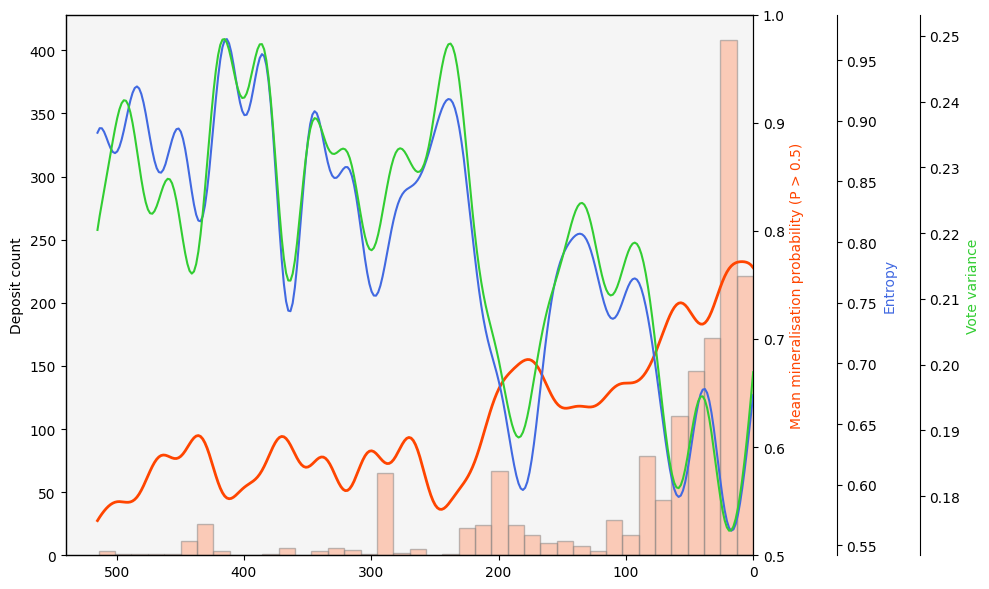

In [25]:
coastline_entropy_high_mean_age = coastline_prob_high.groupby("age (Ma)")["entropy"].mean().reset_index()
coastline_vote_var_high_mean_age = coastline_prob_high.groupby("age (Ma)")["vote_variance"].mean().reset_index()

# Sort by age to ensure correct ordering
coastline_entropy_high_mean_age = coastline_entropy_high_mean_age.sort_values("age (Ma)")
coastline_vote_var_high_mean_age = coastline_vote_var_high_mean_age.sort_values("age (Ma)")

ages_high = coastline_entropy_high_mean_age["age (Ma)"].values.reshape(-1, 1)
entropies_high = coastline_entropy_high_mean_age["entropy"].values.reshape(-1, 1)
vote_vars_high = coastline_vote_var_high_mean_age["vote_variance"].values.reshape(-1, 1)

# Smooth the curves
ages_high_smooth, entropies_high_smooth = smooth_curve(ages_high, entropies_high)
_, vote_vars_high_smooth = smooth_curve(ages_high, vote_vars_high)

# Set up plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_facecolor("whitesmoke")

# Plot histogram
ax1.hist(deposit_coords_recon["age (Ma)"], bins=40, orientation="vertical", color="LightSalmon", alpha=0.5, edgecolor="gray")
ax1.set_ylabel("Deposit count")

# Create secondary y-axis
ax2 = ax1.twinx()

# Plot smoothed probability line
ax2.plot(ages_high_smooth, probs_high_smooth, color="orangered", linewidth=2)
ax2.set_xlim(540, 0)
ax2.set_ylim(0.5, 1)
ax2.set_xlabel("Age (Ma)")
ax2.set_ylabel("Mean mineralisation probability (P > 0.5)", color="orangered")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))  # shift third axis to the right
ax3.plot(ages_high_smooth, entropies_high_smooth,
         linestyle="-", color="royalblue", label="Entropy")
ax3.set_ylabel("Entropy", color="royalblue")

ax4 = ax1.twinx()
ax4.spines["right"].set_position(("outward", 120))  # shift fourth axis to the right
ax4.plot(ages_high_smooth, vote_vars_high_smooth,
         linestyle="-", color="limegreen", label="Vote variance")
ax4.set_ylabel("Vote variance", color="limegreen")
    
plt.tight_layout()
plt.show()

### Global Prospectivity Map of Preserved Porphyry Mineralisation

This code block generates a global grid of preserved mineralisation probability for points within the present-day continental landmasses by averaging their values through time. The grid is created by interpolating these point values, with the interpolation step filling gaps between measurements. We use nearest-neighbor interpolation but mask out grid cells located far from any known data points (based on grid resolution) to avoid misleading extrapolations. The final gridded dataset is saved as compressed NetCDF file.

In [26]:
if not os.path.isfile(coastline_prob_pres_present_day_grid_filename):
    # Create probability grid for the points within present-day continental landmasses
    xmin, xmax, ymin, ymax = -180, 180, -90, 90

    # Create the meshes
    grid_lons = np.arange(xmin, xmax + grid_resolution, grid_resolution)
    grid_lats = np.arange(ymin, ymax + grid_resolution, grid_resolution)
    grid_mlons, grid_mlats = np.meshgrid(grid_lons, grid_lats)

    data_lons = coastline_prob_present_day["present_lon"]
    data_lats = coastline_prob_present_day["present_lat"]
    data_values = coastline_prob_present_day["probability_pres"]

    # Interpolate using the nearest neighbour method
    points = np.column_stack((data_lons, data_lats))
    arr = griddata(points, data_values, (grid_mlons, grid_mlats), method="nearest")  # or "linear", "cubic"

    # Mask distant grid nodes
    tree = cKDTree(points)
    flat_grid_points = np.column_stack((grid_mlons.ravel(), grid_mlats.ravel()))
    distances, _ = tree.query(flat_grid_points, k=1)

    mask = distances > grid_resolution
    arr.ravel()[mask] = np.nan  # Mask out distant nodes        

    # Create the dataset
    dset = xr.Dataset(
        data_vars={
            "z": (("lat", "lon"), arr),
        },
        coords={
            "lon": grid_lons,
            "lat": grid_lats,
        },
    )

    # Set projection info
    dset.rio.write_crs(4326, inplace=True)

    # Save as NetCDF
    dset.to_netcdf(
        coastline_prob_pres_present_day_grid_filename,
        encoding={
            "z": {
                "zlib": True,
                "dtype": "float32",
            }
        },
    )

This cell generates a probability map that displays the probability of preserved mineralisation for points within the present-day continental landmasses, alongside known mineral occurrences. It also plots seafloor age and plate boundaries, including mid-ocean ridges and transform faults. The visualisation highlights spatial patterns, showing how preserved mineralisation probability relates to tectonic features, surface processes, and temporal evolution. It also illustrates how favourable conditions and identified potential areas align with known mineral occurrences.

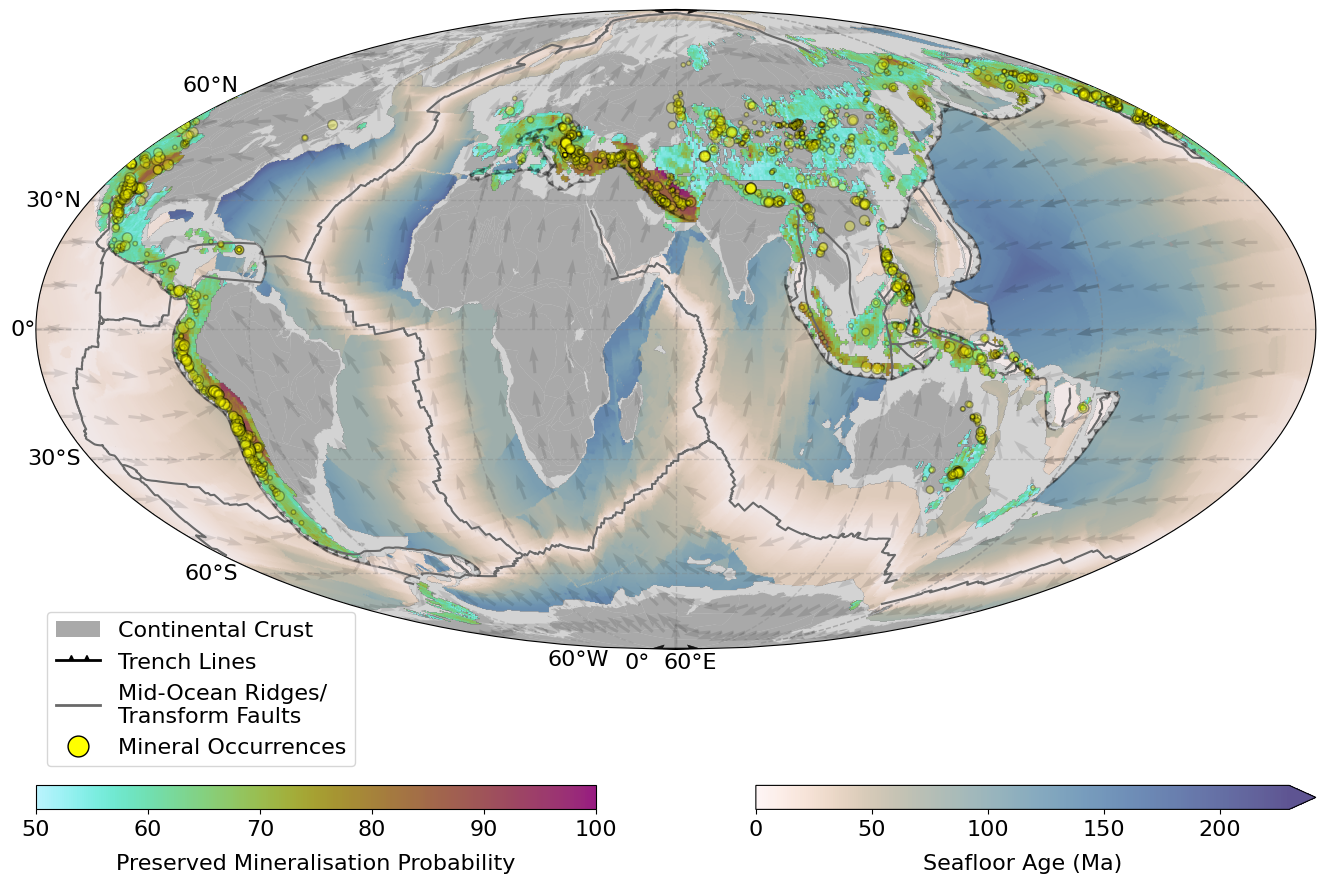

In [27]:
deposit_coords_recon_all = pd.read_csv(deposit_coords_recon_all_filename)
time = 0

gplot.time = time

deposit_coords_recon_t = deposit_coords_recon_all[[f"lon_{time}", f"lat_{time}", "weight"]]
deposit_coords_recon_t = deposit_coords_recon_t.dropna()

# Present-day seafloor age grid
agegrid_filename =  f"seafloor_age_{time}Ma.nc"
agegrid_file = os.path.join(agegrid_dir, agegrid_filename)    
agegrid = gplately.grids.read_netcdf_grid(agegrid_file)

raster = Raster(coastline_prob_pres_present_day_grid_filename)
raster.data *= 100.0
        
fig = plt.figure(figsize=(16, 12))
ax = fig.add_axes(
    [0.1, 0.1, 0.8, 0.8],
    projection=projection,
    facecolor=(plt.cm.colors.to_rgba("darkgray", alpha=0.5)),
)

# Create axes for colourbars
cax_grd = fig.add_axes([0.1, 0.1, 0.35, 0.02])
cax_bg = fig.add_axes([0.55, 0.1, 0.35, 0.02])

# Plot seafloor age as background
bg = gplot.plot_grid(ax, agegrid.data, cmap=ccm.lapaz_r, vmin=0, vmax=230, alpha=0.7, zorder=1)
# Plot continental areas in dark grey
gplot.plot_coastlines(ax, facecolor="darkgray", edgecolor="none", zorder=2)
# Plot plate motion vectors (arrows showing plate movement direction)
gplot.plot_plate_motion_vectors(ax, spacingX=10, spacingY=10, normalise=True, alpha=0.1, zorder=3)
# Plot the probability grid
grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=50, vmax=100, alpha=0.9, zorder=4)

gplot.plot_ridges(ax, color="dimgray", linewidth=1.5, zorder=5)
gplot.plot_transforms(ax, color="dimgray", linewidth=1.5, zorder=5)
gplot.plot_trenches(ax, color="k", alpha=0.3, zorder=6)
gplot.plot_subduction_teeth(ax, spacing=0.05, color="k", alpha=0.3, zorder=7)

# Plot reconstructed mineral occurrences
sc1 = ax.scatter(
    deposit_coords_recon_t[f"lon_{time}"],
    deposit_coords_recon_t[f"lat_{time}"],
    transform=ccrs.PlateCarree(),
    marker="o",
    facecolor="yellow",
    edgecolor="black",
    s = [w * 10 for w in deposit_coords_recon_t["weight"]],
    alpha=0.3,
    zorder=8
)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, x_inline=False, linewidth=1, color="gray", alpha=0.3, linestyle="--", zorder=9)

ax.text(0.49,-0.03, "60°E", transform=ax.transAxes, fontsize=16)
ax.text(0.46,-0.03, "0°", transform=ax.transAxes, fontsize=16)
ax.text(0.40,-0.025, "60°W", transform=ax.transAxes, fontsize=16)

gl.top_labels=False
gl.bottom_labels=False

gl.xlabel_style = {"size": 16}
gl.ylabel_style = {"size": 16}

# Add a colourbar for the mineralisation probability
cbar_grd = fig.colorbar(grd, cax=cax_grd, orientation="horizontal")
cbar_grd.set_label("Preserved Mineralisation Probability", fontsize=16, labelpad=10)
cbar_grd.ax.tick_params(labelsize=16)

# Add a colourbar for seafloor age
cbar_bg = fig.colorbar(bg, cax=cax_bg, orientation="horizontal", extend="max")
cbar_bg.set_label("Seafloor Age (Ma)", fontsize=16, labelpad=10)
cbar_bg.set_ticks([0, 50, 100, 150, 200])
cbar_bg.ax.tick_params(labelsize=16)

# Dummy handle to trigger custom handler
trench_handle = Line2D([], [], color="black")

# Add custom handles
custom_handles = [
    Patch(facecolor="darkgray", edgecolor="none"),
    trench_handle,
    Line2D([0], [0], color="dimgray", lw=2),
    Line2D([0], [0], marker="o", markerfacecolor="yellow", markeredgecolor="black", markersize=15, linestyle="None"),
]
custom_labels = [
    "Continental Crust",
    "Trench Lines",
    "Mid-Ocean Ridges/\nTransform Faults",
    "Mineral Occurrences",
]

# Draw legend
ax.legend(custom_handles, custom_labels, fontsize=16, loc="lower left", bbox_to_anchor=(0, -0.2),
          handler_map={trench_handle: HandlerTrenchLine()})

#     ax.set_title("Global Prospectivity Map of Preserved Porphyry Mineralisation", fontsize=25, y=1.04)

plt.show()

### Prediction-Area Plot

This code segment generates a Prediction–Area (P–A) plot, a valuable tool for assessing the effectiveness of the model in predicting porphyry preserved mineralisation. The P–A plot quantitatively compares the spatial distribution of predicted probabilities with the known locations of mineral occurrences.

For each known mineral occurrence, the corresponding probability value is extracted from the raster grid by selecting the nearest grid cell to the occurrence's geographic coordinates. This provides insights into the model's precision and efficiency in targeting exploration areas.

The analysis considers a range of probability thresholds from 0 to 1. For each threshold, two key percentages are computed:

- **Occurrence Percentage**: The proportion of known mineral occurrences with predicted probabilities greater than or equal to the threshold. This measures how many actual deposits are captured by a given probability cutoff.
- **Area Percentage**: The proportion of the study area with predicted probabilities exceeding the same threshold. This represents how much geographic area would need to be explored if the threshold were applied as a filter.

The resulting curve illustrates model performance by showing how increasing the probability cutoff reduces the exploration area but may also exclude some known occurrences.

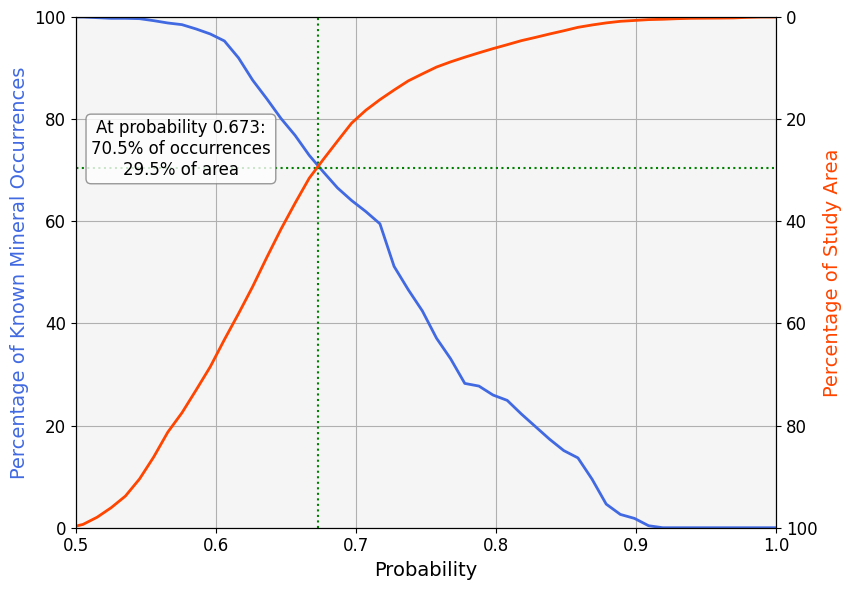

In [28]:
# Load prospectivity data
prospectivity_data = xr.open_dataset(coastline_prob_pres_present_day_grid_filename)
prospectivity_data = prospectivity_data["z"].squeeze()

# Extract probability values at known mineral occurrence locations
occurrence_probabilities = []
for _, row in deposit_coords_recon.iterrows():
    lon, lat = row["present_lon"], row["present_lat"]
    # Extract probability value at this point
    prob_value = prospectivity_data.sel(lon=lon, lat=lat, method="nearest").item()
    occurrence_probabilities.append(prob_value)

# Convert to numpy array for easier manipulation
occurrence_probabilities = np.array(occurrence_probabilities)
occurrence_probabilities = occurrence_probabilities[~np.isnan(occurrence_probabilities)]

# Calculate total study area and number of valid cells
total_area = np.count_nonzero(~np.isnan(prospectivity_data))
total_occurrences = len(occurrence_probabilities)

# Define the probability thresholds
thresholds = np.linspace(0, 1, 100)

# Initialize lists to store results
occurrence_percentages = []
area_percentages = []

# Calculate percentages for each threshold
for threshold in thresholds:
    occurrence_percentage = np.sum(occurrence_probabilities >= threshold) / total_occurrences * 100
    area_percentage = np.sum(prospectivity_data >= threshold) / total_area * 100
    occurrence_percentages.append(occurrence_percentage)
    area_percentages.append(area_percentage)

# Convert lists to numpy arrays for plotting
occurrence_percentages = np.array(occurrence_percentages)
area_percentages = np.array(area_percentages)

# Set the font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
LARGE_SIZE = 16

# Create the P-A plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_facecolor("whitesmoke")

# Plot the occurrence percentages
ax1.plot(thresholds, occurrence_percentages, color="royalblue", linewidth=2)
ax1.set_xlabel("Probability", fontsize=MEDIUM_SIZE)
ax1.set_ylabel("Percentage of Known Mineral Occurrences", color="royalblue", fontsize=MEDIUM_SIZE)
ax1.set_ylim(0, 100)
ax1.set_xlim(0.5, 1)
ax1.grid(True)

# Set tick label sizes
ax1.tick_params(axis="both", labelsize=SMALL_SIZE)

# Create a second y-axis to plot the area percentages
ax2 = ax1.twinx()
ax2.plot(thresholds, area_percentages, color="orangered", linewidth=2)
ax2.set_ylabel("Percentage of Study Area", color="orangered", fontsize=MEDIUM_SIZE)
ax2.set_ylim(100, 0)  # Inverted y-axis
ax2.tick_params(axis="y", labelsize=SMALL_SIZE)

# Add horizontal and vertical lines
intersection_x = 0.673
intersection_y1 = 70.5
intersection_y2 = 29.5
h_line = ax1.hlines(y=intersection_y1, xmin=0, xmax=1, color="g", linestyles=":")
v_line = ax1.vlines(x=intersection_x, ymin=0, ymax=100, color="g", linestyles=":")

# Add annotations for the lines
# X-axis annotation
# ax1.annotate(f"{intersection_x}", xy=(intersection_x, -0.06), xycoords="data",
#              xytext=(0, -20), textcoords="offset points",
#              ha="center", va="top", color="g",
#              arrowprops=dict(arrowstyle="->", color="g"))

# # Left Y-axis (Percentage of Known Mineral Occurrences) annotation
# ax1.annotate(f"{intersection_y1}%", xy=(0, intersection_y1), xycoords="data",
#              xytext=(-25, 0), textcoords="offset points",
#              ha="right", va="center", color="g",
#              arrowprops=dict(arrowstyle="->", color="g", shrinkA=0, shrinkB=4))

# # Right Y-axis (Percentage of Study Area) annotation
# ax2.annotate(f"{intersection_y2}%", xy=(1, intersection_y2), xycoords="data",
#              xytext=(25, 0), textcoords="offset points",
#              ha="left", va="center", color="g",
#              arrowprops=dict(arrowstyle="->", color="g", shrinkA=0, shrinkB=4))

# Add a text box to explain the intersection point
ax1.annotate(f"At probability {intersection_x}:\n{intersection_y1}% of occurrences\n{intersection_y2}% of area",
             xy=(0.15, 0.8), xycoords="axes fraction",
             ha="center", va="top",
             fontsize=SMALL_SIZE,
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

# plt.title("Prediction-Area Plot")
plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Adjust the plot margins to make room for annotations
plt.subplots_adjust(left=0.15, right=0.85)

plt.show()